# Combined Clustering: Poets + Quran

Two experiments, both using the exact same method as the poetry paper
(Arabic-SBERT-100K embeddings → UMAP → HDBSCAN), applied to a combined
pool of "authors":

- **Experiment 1:** the entire Quran treated as ONE author (114 surahs =
  114 "poems" by that one author) mixed in with the 260 real poets →
  **261 authors total**.
- **Experiment 2:** each of the 114 surahs treated as its OWN separate
  author, mixed in with the 260 real poets → **374 authors total**.

**Important framing before you read results:** pre-Islamic poetry and the
Quran are different genres, different eras, different linguistic
registers, and different rhetorical purposes on their face — classical
Islamic scholarship itself treats the Quran's literary form as
categorically distinct from poetry (a concept called *i'jaz al-Quran*,
the Quran's "inimitability"). So if the Quran (or surahs) land in their
own cluster, separate from all poets, **that is the expected, unsurprising
result** — it mainly confirms "this is a different genre," not anything
about authorship. The more informative outcome to watch for is the
opposite: if surahs scatter unpredictably among poet clusters, or a
poet's style lands unusually close to the Quran's.

**Before you start:** put `poems.db` in the same folder as this notebook
(same file as the paper-reproduction notebook — reused here).

Run cells top to bottom, **Shift+Enter**. ~30-50 min total (embeds ~19k
poetry verses + ~6k Quran ayat once, then two separate clustering runs).

In [1]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 -- Configuration (same values as the paper-reproduction notebook)
import re, sqlite3, hashlib, json, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")

DB_PATH = Path("poems.db")
CACHE_DIR = Path("quran_cache"); CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("output/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"
MAX_TOKENS_PER_POEM = 512
MAX_VERSES_PER_POEM = 20

UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 50
UMAP_METRIC = "cosine"
HDBSCAN_MIN_CLUSTER_SIZE = 5
HDBSCAN_MIN_SAMPLES = 3

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU (slower).")

def split_verses(poem_text):
    # Same verse-splitting regex used throughout -- splits on newlines and
    # Arabic/Latin sentence punctuation.
    if not poem_text or not isinstance(poem_text, str):
        return []
    verses = re.split(r'[\n\r]+|[.!\u061F?\u061B;]+', poem_text)
    return [v.strip() for v in verses if len(v.strip()) > 10]

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})
print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


## Step 1 — Load both text sources

Loads the 260 poets from `poems.db` and fetches all 114 Quran surahs from
the same public API used before.

In [3]:
# CELL 3 -- Load the 260 poets from poems.db
conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query(
    "SELECT poet_name, poem_title, poem_text, poem_type, poem_meter, verses_count "
    "FROM poems WHERE poet_name IS NOT NULL AND poem_text IS NOT NULL "
    "AND LENGTH(poem_text) >= 50",
    conn,
)
conn.close()

df["poem_hash"] = df["poem_text"].apply(lambda t: hashlib.md5(t.strip().encode("utf-8")).hexdigest())
df = df.drop_duplicates(subset=["poem_hash"]).copy()

poems_by_poet = defaultdict(list)
for _, row in df.iterrows():
    poems_by_poet[row["poet_name"]].append(row["poem_text"])
poems_by_poet = dict(poems_by_poet)

print(f"Poets loaded: {len(poems_by_poet)}")
print(f"Poems loaded: {len(df)}")

Poets loaded: 260
Poems loaded: 2328


In [4]:
# CELL 4 -- Fetch Quran text (cached locally after first run)
cache_file = CACHE_DIR / "quran_ayat.json"

if cache_file.exists():
    print("Loading Quran from local cache...")
    with open(cache_file, encoding="utf-8") as f:
        surahs_raw = json.load(f)
else:
    print("Fetching Quran from Al Quran Cloud API...")
    resp = requests.get("https://api.alquran.cloud/v1/quran/quran-uthmani", timeout=60)
    resp.raise_for_status()
    surahs_raw = resp.json()["data"]["surahs"]
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(surahs_raw, f, ensure_ascii=False)
    print("Fetched and cached.")

# Build: surah_number -> "poem text" where ayat are newline-joined so the
# SAME split_verses function used for poetry correctly recovers each ayah
# as one verse.
surah_names = {}
surah_poem_text = {}
for s in surahs_raw:
    snum = s["number"]
    surah_names[snum] = s["englishName"]
    ayat_texts = [a["text"] for a in s["ayahs"]]
    surah_poem_text[snum] = "\n".join(ayat_texts)

print(f"Surahs loaded: {len(surah_poem_text)}")
total_ayat = sum(len(split_verses(t)) for t in surah_poem_text.values())
print(f"Total ayat recovered via split_verses: {total_ayat} (should be ~6236)")

Fetching Quran from Al Quran Cloud API...
Fetched and cached.
Surahs loaded: 114
Total ayat recovered via split_verses: 6235 (should be ~6236)


## Step 2 — Embed everything once

Same embedding function used in the paper reproduction (verse → poem →
author hierarchical average). Run once for the 260 poets, once for the
114 surahs — the resulting vectors get reused in both experiments below,
so nothing gets embedded twice.

In [5]:
# CELL 5 -- Embed the 260 poets (proposed method: verse -> poem -> poet)
from sentence_transformers import SentenceTransformer

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded. Embedding dim:", model.get_sentence_embedding_dimension())

def _encode(texts, batch_size=64):
    if not texts:
        return np.array([])
    return model.encode(texts, batch_size=batch_size, show_progress_bar=False,
                         normalize_embeddings=True, convert_to_numpy=True)

def embed_poem_verse_average(poems_by_author, max_verses=MAX_VERSES_PER_POEM, seed=RANDOM_SEED):
    # verse -> poem -> author hierarchical mean, same as the paper's proposed method
    out = {}
    rng = np.random.RandomState(seed)
    for author, poems in poems_by_author.items():
        poem_vectors = []
        for poem in poems:
            verses = split_verses(poem)
            if len(verses) > max_verses:
                idx = rng.choice(len(verses), max_verses, replace=False)
                verses = [verses[i] for i in sorted(idx)]
            if verses:
                poem_vectors.append(np.mean(_encode(verses), axis=0))
        if poem_vectors:
            out[author] = np.mean(poem_vectors, axis=0)
    return out

print("\nEmbedding 260 poets (this is the slow step)...")
poet_embeddings = embed_poem_verse_average(poems_by_poet)
print(f"Done. {len(poet_embeddings)} poets embedded.")

Loading model: akhooli/Arabic-SBERT-100K


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded. Embedding dim: 768

Embedding 260 poets (this is the slow step)...
Done. 260 poets embedded.


In [6]:
# CELL 6 -- Embed the 114 surahs (each surah's ayat averaged into one vector)
print("Embedding 114 surahs...")
surah_vectors = {}
for snum, poem_text in surah_poem_text.items():
    verses = split_verses(poem_text)
    if verses:
        surah_vectors[snum] = np.mean(_encode(verses), axis=0)

print(f"Done. {len(surah_vectors)} surahs embedded.")

# The single "Quran (whole)" author vector for Experiment 1 = average of
# all 114 surah vectors (mirrors "author = average of their poems" exactly,
# since each surah-vector already IS that surah's poem-level vector).
quran_whole_vector = np.mean(list(surah_vectors.values()), axis=0)
print("Combined whole-Quran vector computed.")

Embedding 114 surahs...
Done. 114 surahs embedded.
Combined whole-Quran vector computed.


## Experiment 1 — Quran as ONE author (261 total)

The 260 poets, plus one more entry: "Quran (whole)". Clustered together
with the exact same UMAP + HDBSCAN settings as the paper.

In [7]:
# CELL 7 -- Experiment 1: cluster 261 (260 poets + whole Quran)
import umap, hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

def cluster_and_report(embeddings_dict, label_types, title, n_neighbors=UMAP_N_NEIGHBORS,
                       min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE):
    names = sorted(embeddings_dict.keys())
    n = len(names)
    emb_matrix = np.array([embeddings_dict[nm] for nm in names])

    umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, n - 1), n_neighbors, 0.0, UMAP_METRIC)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=HDBSCAN_MIN_SAMPLES,
                                cluster_selection_method="eom", metric="euclidean")
    labels = clusterer.fit_predict(umap_high)
    umap_2d = run_umap(emb_matrix, 2, n_neighbors, UMAP_MIN_DIST, UMAP_METRIC)

    mask = labels >= 0
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    n_outliers = int(np.sum(labels == -1))
    sil = float(silhouette_score(umap_high[mask], labels[mask])) if n_clusters >= 2 and mask.sum() > n_clusters else None

    result_df = pd.DataFrame({
        "name": names, "type": [label_types[nm] for nm in names],
        "cluster": labels, "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1],
    })

    print(f"=== {title} ===")
    print(f"Total entities: {n} | Clusters: {n_clusters} | Outliers: {n_outliers} | Silhouette: {sil}")
    return result_df, {"n_entities": n, "n_clusters": n_clusters, "n_outliers": n_outliers, "silhouette": sil}, sim_matrix_for(emb_matrix, names)

def sim_matrix_for(emb_matrix, names):
    return names, cosine_similarity(emb_matrix)

# Build the 261-entity set
exp1_embeddings = dict(poet_embeddings)
exp1_embeddings["Quran (whole)"] = quran_whole_vector
exp1_types = {nm: ("Quran" if nm == "Quran (whole)" else "Poet") for nm in exp1_embeddings}

exp1_df, exp1_metrics, (exp1_names, exp1_sim) = cluster_and_report(
    exp1_embeddings, exp1_types, "Experiment 1: 260 poets + Quran (whole) = 261"
)
exp1_df.to_csv(TABLES_DIR / "experiment1_clusters.csv", index=False)

# Where did the Quran land?
quran_row = exp1_df[exp1_df["name"] == "Quran (whole)"].iloc[0]
print(f"\nQuran (whole) landed in cluster: {quran_row['cluster']}")
same_cluster = exp1_df[(exp1_df["cluster"] == quran_row["cluster"]) & (exp1_df["name"] != "Quran (whole)")]
print(f"Other members of that cluster ({len(same_cluster)} poets):")
print(same_cluster["name"].tolist())

# Nearest-neighbor poets to the Quran by raw cosine similarity
qidx = exp1_names.index("Quran (whole)")
sims = exp1_sim[qidx].copy(); sims[qidx] = -1
top5_idx = np.argsort(sims)[-5:][::-1]
print("\nTop 5 most similar poets to the Quran (by raw cosine similarity):")
for i in top5_idx:
    print(f"  {exp1_names[i]}: {sims[i]:.4f}")

with open(REPORTS_DIR / "experiment1_metrics.json", "w") as f:
    json.dump(exp1_metrics, f, indent=2)

=== Experiment 1: 260 poets + Quran (whole) = 261 ===
Total entities: 261 | Clusters: 13 | Outliers: 40 | Silhouette: 0.46884259581565857

Quran (whole) landed in cluster: 1
Other members of that cluster (19 poets):
['أبو بثينه الهذلي', 'أبو حسان الفزاري', 'أوس الهجيمي', 'ابن شعواء الفزاري', 'ابن كلاب العقيلي', 'الأشعث الجاشي', 'الأعرج المري', 'السليك بن السلكة', 'الكلحبة العرني', 'المثلم الفزاري', 'المعان بن روق', 'النابغة التغلبي', 'الهجرس التغلبي', 'امرؤ القيس الزهيري', 'جبار الفزاري', 'سنان المري', 'نهيكة الفزاري', 'هند الفزارية', 'هند بنت الخس']

Top 5 most similar poets to the Quran (by raw cosine similarity):
  ابن شعواء الفزاري: 0.9762
  نهيكة الفزاري: 0.9754
  بدر الفزاري: 0.9723
  دوسر بن هذيل: 0.9719
  الهجرس التغلبي: 0.9707


## Experiment 2 — Each surah as its OWN author (374 total)

The same 260 poets, plus each of the 114 surahs entered as a separate,
independent "author." Clustered together with the same settings.

In [8]:
# CELL 8 -- Experiment 2: cluster 374 (260 poets + 114 individual surahs)
exp2_embeddings = dict(poet_embeddings)
for snum, vec in surah_vectors.items():
    exp2_embeddings[f"Surah {snum}: {surah_names[snum]}"] = vec
exp2_types = {nm: ("Surah" if nm.startswith("Surah ") else "Poet") for nm in exp2_embeddings}

exp2_df, exp2_metrics, (exp2_names, exp2_sim) = cluster_and_report(
    exp2_embeddings, exp2_types, "Experiment 2: 260 poets + 114 surahs = 374"
)
exp2_df.to_csv(TABLES_DIR / "experiment2_clusters.csv", index=False)

# How do surahs distribute across clusters relative to poets?
surah_rows = exp2_df[exp2_df["type"] == "Surah"]
cluster_composition = exp2_df.groupby("cluster")["type"].value_counts().unstack(fill_value=0)
print("\nCluster composition (poets vs surahs per cluster):")
print(cluster_composition)

surah_only_clusters = cluster_composition[(cluster_composition.get("Poet", 0) == 0) & (cluster_composition.index != -1)]
mixed_clusters = cluster_composition[(cluster_composition.get("Poet", 0) > 0) & (cluster_composition.get("Surah", 0) > 0)]
print(f"\nClusters made ENTIRELY of surahs (no poets): {len(surah_only_clusters)}")
print(f"MIXED clusters (both poets and surahs together): {len(mixed_clusters)}")
if len(mixed_clusters) > 0:
    print("\nMixed clusters -- poets sharing a cluster with at least one surah:")
    for cl in mixed_clusters.index:
        members = exp2_df[exp2_df["cluster"] == cl]
        poets_in = members[members["type"] == "Poet"]["name"].tolist()
        surahs_in = members[members["type"] == "Surah"]["name"].tolist()
        print(f"  Cluster {cl}: poets={poets_in} | surahs={surahs_in}")

surah_outliers = surah_rows[surah_rows["cluster"] == -1]
print(f"\nSurahs classified as outliers (fit no cluster): {len(surah_outliers)} / {len(surah_rows)}")

with open(REPORTS_DIR / "experiment2_metrics.json", "w") as f:
    json.dump(exp2_metrics, f, indent=2)

=== Experiment 2: 260 poets + 114 surahs = 374 ===
Total entities: 374 | Clusters: 12 | Outliers: 11 | Silhouette: 0.46887871623039246

Cluster composition (poets vs surahs per cluster):
type     Poet  Surah
cluster             
-1         10      1
 0          0     61
 1          3     22
 2          4      2
 3          0     15
 4          8      0
 5          0      8
 6          9      5
 7         27      0
 8         14      0
 9          7      0
 10       102      0
 11        76      0

Clusters made ENTIRELY of surahs (no poets): 3
MIXED clusters (both poets and surahs together): 4

Mixed clusters -- poets sharing a cluster with at least one surah:
  Cluster -1: poets=['آمنة بنت عتيبة', 'أبو قيس بن رفاعة', 'أزبر بن غزي', 'الأعرج المري', 'الخنساء بنت التيجان', 'المرار الكلبي', 'النابغة الغنوي', 'الهيبان الفهمي', 'هند بنت الخس', 'يزيد الأرحبي'] | surahs=['Surah 111: Al-Masad']
  Cluster 1: poets=['ابن جوين الطائي', 'السلكة أم السليك', 'العوراء الذبيانية'] | surahs=['Surah 100

## Figures

UMAP scatter for each experiment, poets in one color, Quran/surahs marked
distinctly so you can see at a glance where they land.

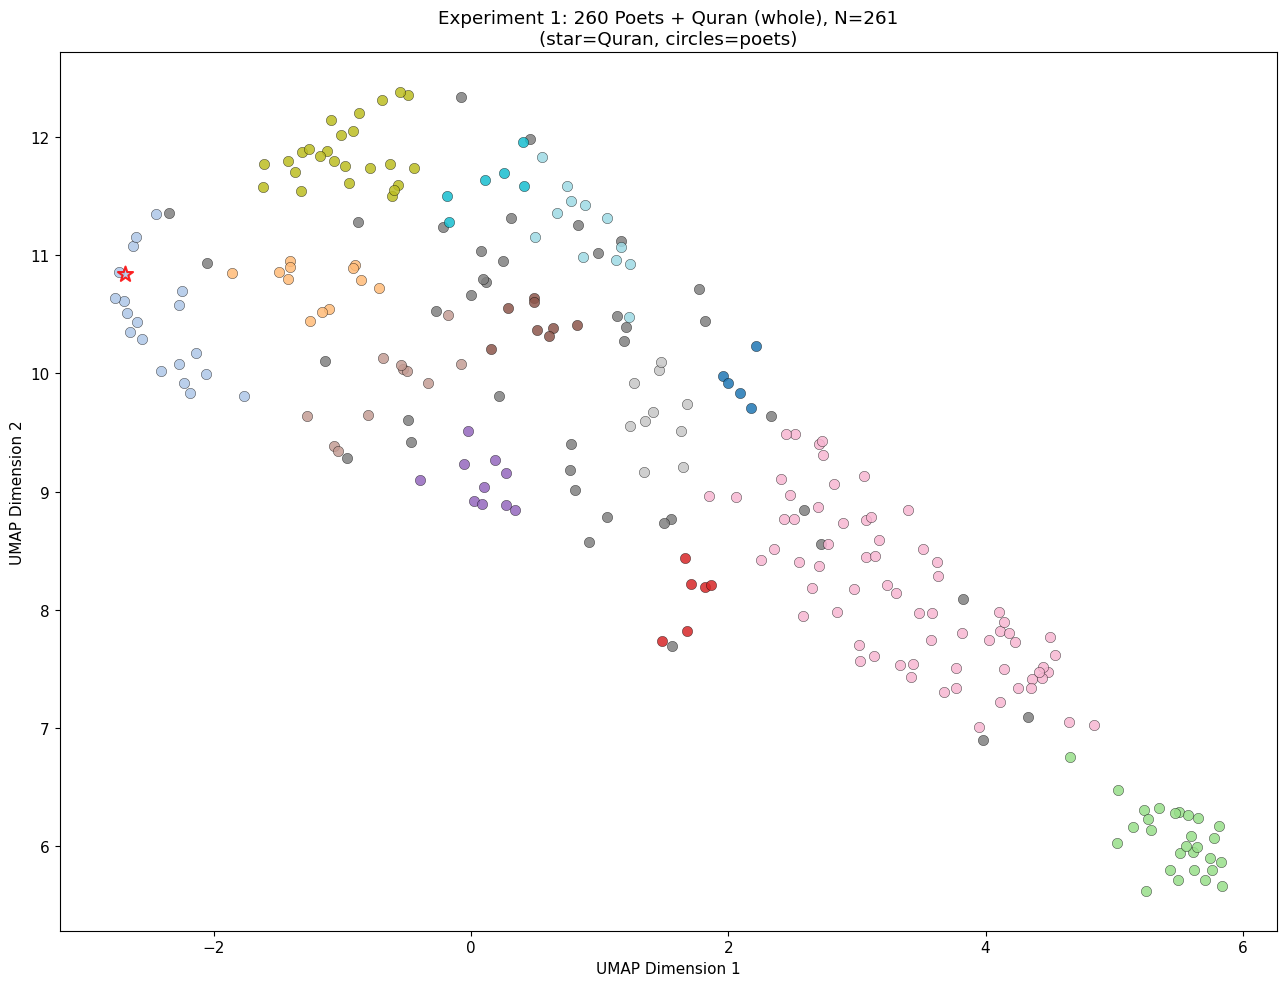

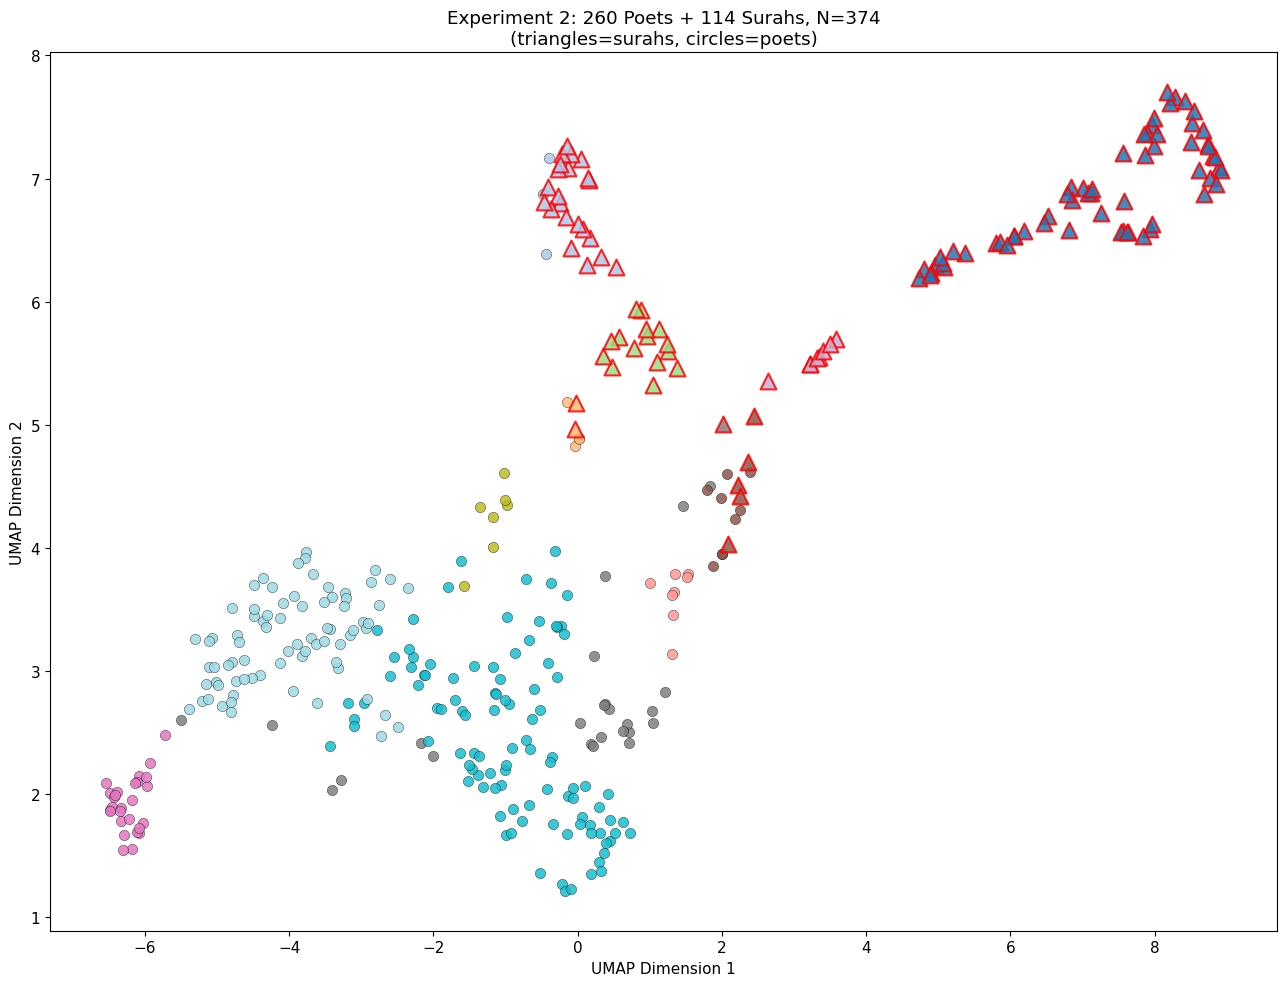

Figures saved to output/figures/


In [9]:
# CELL 9 -- Figures for both experiments
def plot_experiment(df, title, save_name, type_colors):
    fig, ax = plt.subplots(figsize=(13, 10))
    unique_clusters = sorted(df["cluster"].unique())
    palette = plt.cm.tab20(np.linspace(0, 1, max(len([c for c in unique_clusters if c >= 0]), 1)))
    for cl in unique_clusters:
        sub = df[df["cluster"] == cl]
        for t, marker in type_colors.items():
            tsub = sub[sub["type"] == t]
            if len(tsub) == 0:
                continue
            color = "gray" if cl == -1 else palette[cl % len(palette)]
            size = 130 if t != "Poet" else 55
            edge = "red" if t != "Poet" else "black"
            lw = 1.5 if t != "Poet" else 0.3
            ax.scatter(tsub["umap_x"], tsub["umap_y"], c=[color], marker=marker, s=size,
                      alpha=0.85, edgecolors=edge, linewidth=lw)
    ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / save_name, dpi=300, bbox_inches="tight")
    plt.show()

plot_experiment(exp1_df, "Experiment 1: 260 Poets + Quran (whole), N=261\n(star=Quran, circles=poets)",
                "experiment1_umap.png", {"Poet": "o", "Quran": "*"})

plot_experiment(exp2_df, "Experiment 2: 260 Poets + 114 Surahs, N=374\n(triangles=surahs, circles=poets)",
                "experiment2_umap.png", {"Poet": "o", "Surah": "^"})

print("Figures saved to output/figures/")

In [10]:
# CELL 10 -- Final report
report_path = REPORTS_DIR / "combined_experiments_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("COMBINED CLUSTERING: POETS + QURAN\n")
    f.write("=" * 70 + "\n\n")

    f.write("EXPERIMENT 1: 260 poets + Quran as ONE author (N=261)\n" + "-" * 50 + "\n")
    for k, v in exp1_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  Quran's cluster: {quran_row['cluster']}\n")
    f.write(f"  Poets sharing that cluster: {len(same_cluster)}\n")
    if len(same_cluster) > 0:
        f.write(f"    {same_cluster['name'].tolist()}\n")
    f.write("  Top 5 most similar poets to the Quran (cosine similarity):\n")
    for i in top5_idx:
        f.write(f"    {exp1_names[i]}: {sims[i]:.4f}\n")

    f.write("\nEXPERIMENT 2: 260 poets + 114 individual surahs (N=374)\n" + "-" * 50 + "\n")
    for k, v in exp2_metrics.items():
        f.write(f"  {k}: {v}\n")
    f.write(f"  Surah-only clusters (no poets): {len(surah_only_clusters)}\n")
    f.write(f"  Mixed clusters (poets + surahs together): {len(mixed_clusters)}\n")
    f.write(f"  Surahs classified as outliers: {len(surah_outliers)} / {len(surah_rows)}\n")

    f.write("\nHOW TO READ THIS\n" + "-" * 50 + "\n")
    f.write("  Poetry and Quranic text are different genres, eras, and\n")
    f.write("  registers on their face. If the Quran/surahs land in their\n")
    f.write("  own separate cluster(s), that is the EXPECTED result -- it\n")
    f.write("  mainly confirms genre difference, not anything about\n")
    f.write("  authorship. The more informative signal is the opposite:\n")
    f.write("  any poet landing in the same cluster as the Quran, or\n")
    f.write("  surahs scattering broadly across poet clusters instead of\n")
    f.write("  staying together, would be the surprising/notable finding.\n")
    f.write("  This method measures writing-style similarity; it cannot\n")
    f.write("  establish or rule out claims about authorship.\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\combined_experiments_report.txt

COMBINED CLUSTERING: POETS + QURAN

EXPERIMENT 1: 260 poets + Quran as ONE author (N=261)
--------------------------------------------------
  n_entities: 261
  n_clusters: 13
  n_outliers: 40
  silhouette: 0.46884259581565857
  Quran's cluster: 1
  Poets sharing that cluster: 19
    ['أبو بثينه الهذلي', 'أبو حسان الفزاري', 'أوس الهجيمي', 'ابن شعواء الفزاري', 'ابن كلاب العقيلي', 'الأشعث الجاشي', 'الأعرج المري', 'السليك بن السلكة', 'الكلحبة العرني', 'المثلم الفزاري', 'المعان بن روق', 'النابغة التغلبي', 'الهجرس التغلبي', 'امرؤ القيس الزهيري', 'جبار الفزاري', 'سنان المري', 'نهيكة الفزاري', 'هند الفزارية', 'هند بنت الخس']
  Top 5 most similar poets to the Quran (cosine similarity):
    ابن شعواء الفزاري: 0.9762
    نهيكة الفزاري: 0.9754
    بدر الفزاري: 0.9723
    دوسر بن هذيل: 0.9719
    الهجرس التغلبي: 0.9707

EXPERIMENT 2: 260 poets + 114 individual surahs (N=374)
--------------------------------------------------
  n_ent

## Done

Output in `output/`:
- `output/tables/experiment1_clusters.csv`, `experiment2_clusters.csv` —
  full cluster assignment for every poet, the Quran, and every surah
- `output/figures/` — UMAP scatter plots for both experiments
- `output/reports/combined_experiments_report.txt` — summary with both
  experiments' numbers and the "how to read this" note

Send that report + the two figures to your professor — they show exactly
where the Quran (Experiment 1) and each surah (Experiment 2) landed
relative to the 260 poets.